In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, List

### Inicjalizacja Populacji
Tworzymy początkową populację rozwiązań, liczymy ich wartości funkcji celu i wybieramy najlepsze.

In [2]:
def initialize_population(n_bees: int, dim: int, bounds: Tuple[float, float], objective_func: Callable):

    food_sources = np.random.uniform(bounds[0], bounds[1], (n_bees, dim))
    fitness = np.array([objective_func(source) for source in food_sources])
    trial_counter = np.zeros(n_bees)

    best_idx = np.argmin(fitness)
    best_solution = food_sources[best_idx].copy()
    best_fitness = fitness[best_idx]

    return food_sources, fitness, trial_counter, best_solution, best_fitness


### Produkcja nowego rozwiązania
To implementacja wzoru (7) z ABC — pszczoła modyfikuje jedno z wymiarów swojego rozwiązania, korzystając z różnicy względem innej pszczoły.

In [3]:
def produce_new_solution(food_sources: np.ndarray, bee_idx: int, bounds: Tuple[float, float]) -> np.ndarray:
    
    dim = food_sources.shape[1]
    new_solution = food_sources[bee_idx].copy()

    j = np.random.randint(0, dim)
    k = np.random.randint(0, food_sources.shape[0])
    while k == bee_idx:
        k = np.random.randint(0, food_sources.shape[0])

    phi = np.random.uniform(-1, 1)
    new_solution[j] = food_sources[bee_idx, j] + phi * (food_sources[bee_idx, j] - food_sources[k, j])
    new_solution[j] = np.clip(new_solution[j], bounds[0], bounds[1])

    return new_solution

### Faza pszczół zatrudnionych
Każda pszczoła próbuje ulepszyć swoje rozwiązanie. Jeśli się uda, aktualizujemy najlepsze rozwiązanie.

In [4]:
def employed_bees_phase(food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func):

    for i in range(food_sources.shape[0]):
        new_solution = produce_new_solution(food_sources, i, bounds)
        new_fitness = objective_func(new_solution)

        if new_fitness < fitness[i]:
            food_sources[i] = new_solution
            fitness[i] = new_fitness
            trial_counter[i] = 0
            if new_fitness < best_fitness:
                best_solution = new_solution.copy()
                best_fitness = new_fitness
        else:
            trial_counter[i] += 1

    return food_sources, fitness, trial_counter, best_solution, best_fitness

### Selekcja ruletką
To mechanizm wyboru źródła przez pszczoły obserwatorki — im lepsze źródło, tym większa szansa, że zostanie wybrane.

In [5]:
def roulette_wheel_selection(probabilities: np.ndarray) -> int:

    r = np.random.random()
    cumsum = np.cumsum(probabilities)
    return np.searchsorted(cumsum, r)

### Faza pszczół obserwatorek
Obserwatorki wybierają źródła na podstawie prawdopodobieństwa i próbują je ulepszyć.

In [6]:
def onlooker_bees_phase(food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func):
    """Pszczoły obserwatorki wybierają źródła probabilistycznie i próbują je ulepszyć."""
    fitness_sum = np.sum(1.0 / (1.0 + fitness))
    probabilities = (1.0 / (1.0 + fitness)) / fitness_sum

    for i in range(food_sources.shape[0]):
        selected_idx = roulette_wheel_selection(probabilities)
        new_solution = produce_new_solution(food_sources, selected_idx, bounds)
        new_fitness = objective_func(new_solution)

        if new_fitness < fitness[selected_idx]:
            food_sources[selected_idx] = new_solution
            fitness[selected_idx] = new_fitness
            trial_counter[selected_idx] = 0
            if new_fitness < best_fitness:
                best_solution = new_solution.copy()
                best_fitness = new_fitness
        else:
            trial_counter[selected_idx] += 1

    return food_sources, fitness, trial_counter, best_solution, best_fitness

### Faza pszczół zwiadowców
Jeśli źródło jest „martwe” (nie poprawia się), zastępujemy je nowym losowym rozwiązaniem.

In [7]:
def scout_bees_phase(food_sources, fitness, trial_counter, bounds, objective_func, limit):

    max_trial_idx = np.argmax(trial_counter)
    if trial_counter[max_trial_idx] >= limit:
        food_sources[max_trial_idx] = np.random.uniform(bounds[0], bounds[1], food_sources.shape[1])
        fitness[max_trial_idx] = objective_func(food_sources[max_trial_idx])
        trial_counter[max_trial_idx] = 0
    return food_sources, fitness, trial_counter

## Główna pętla optymalizacji
Łączy wszystkie fazy w jedną pętlę optymalizacji. Zwraca najlepsze rozwiązanie, jego wartość i historię zbieżności.

In [8]:
def artificial_bee_colony(n_bees, dim, bounds, max_iter, objective_func, limit=None):
    """Główna funkcja optymalizacji ABC."""
    if limit is None:
        limit = n_bees * dim

    food_sources, fitness, trial_counter, best_solution, best_fitness = initialize_population(n_bees, dim, bounds, objective_func)
    convergence_curve = [best_fitness]

    for iteration in range(max_iter):
        food_sources, fitness, trial_counter, best_solution, best_fitness = employed_bees_phase(
            food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func
        )
        food_sources, fitness, trial_counter, best_solution, best_fitness = onlooker_bees_phase(
            food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func
        )
        food_sources, fitness, trial_counter = scout_bees_phase(
            food_sources, fitness, trial_counter, bounds, objective_func, limit
        )

        convergence_curve.append(best_fitness)

    return best_solution, best_fitness, convergence_curve

### Wizualizacja
Rysuje krzywą zbieżności algorytmu ABC.

In [9]:
def plot_convergence(convergence_curve):

    plt.figure(figsize=(10, 6))
    plt.plot(convergence_curve, 'b-', linewidth=2)
    plt.xlabel('Iteracja')
    plt.ylabel('Najlepsza wartość funkcji celu')
    plt.title('Krzywa zbieżności algorytmu ABC')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

# Przykład użycia

## Funckje celu

Sferyczna

In [10]:
def sphere_function(x: np.ndarray) -> float:
    return np.sum(x ** 2)

Funkcja Rastrigina

In [11]:
def rastrigin_function(x: np.ndarray, A: float = 10) -> float:

    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

Funkcja Rosenbrocka

In [12]:
def rosenbrock_function(x: np.ndarray) -> float:

    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

## Wywołanie

Najlepsze rozwiązanie: [ 9.41201708e-14  2.77751961e-14  1.67772955e-13  3.44645696e-13
 -7.94059645e-14 -1.92578369e-13  1.79759594e-15  9.63937574e-15
 -8.93857250e-14  2.94500295e-14]
Wartość funkcji: 2.089034844345576e-25


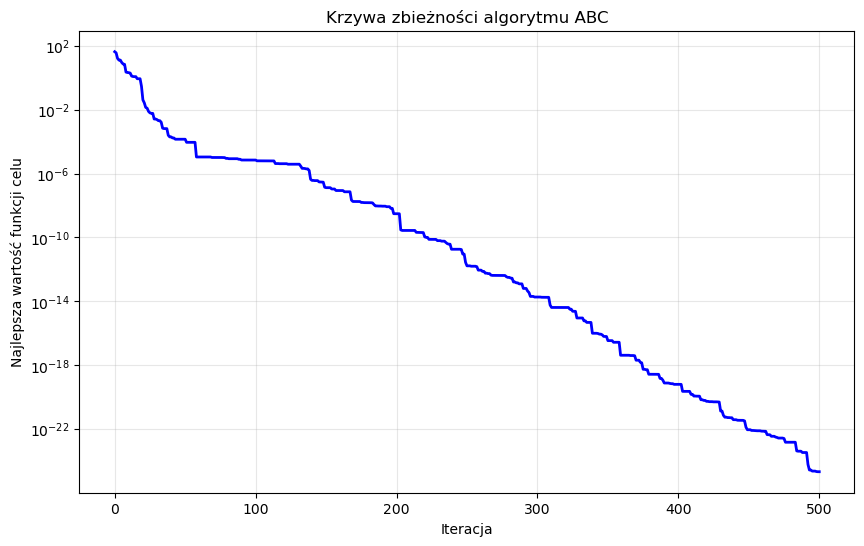

In [13]:
best_solution, best_value, convergence = artificial_bee_colony(
    n_bees=50,
    dim=10,
    bounds=(-5.12, 5.12),
    max_iter=500,
    objective_func = sphere_function
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
plot_convergence(convergence)

## Główna pętla algorytmu z zapisywaniem pozycji agentów

In [14]:
def artificial_bee_colony_position(
    n_bees, dim, bounds, max_iter, objective_func,
    limit=None, save_every=1
):
    """Główna funkcja optymalizacji ABC z logowaniem pozycji agentów."""
    
    if limit is None:
        limit = n_bees * dim

    food_sources, fitness, trial_counter, best_solution, best_fitness = initialize_population(
        n_bees, dim, bounds, objective_func
    )
    convergence_curve = [best_fitness]

    # Log pozycji agentów (tylko dla dim = 2)
    positions_log = []

    # Zapis początkowych pozycji
    if dim == 2 and save_every == 0:
        raise ValueError("save_every musi być >= 1")

    if dim == 2:
        positions_log.append(food_sources.copy())

    for iteration in range(max_iter):

        food_sources, fitness, trial_counter, best_solution, best_fitness = employed_bees_phase(
            food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func
        )
        food_sources, fitness, trial_counter, best_solution, best_fitness = onlooker_bees_phase(
            food_sources, fitness, trial_counter, best_solution, best_fitness, bounds, objective_func
        )
        food_sources, fitness, trial_counter = scout_bees_phase(
            food_sources, fitness, trial_counter, bounds, objective_func, limit
        )

        convergence_curve.append(best_fitness)

        # Zapis pozycji co save_every iteracji
        if dim == 2 and (iteration + 1) % save_every == 0:
            positions_log.append(food_sources.copy())

    return best_solution, best_fitness, convergence_curve, positions_log

### Wywołanie

In [22]:
best_solution, best_value, convergence, position_log = artificial_bee_colony_position(
    n_bees=20,
    dim=2,
    bounds=(-10, 10),
    max_iter=50,
    objective_func = sphere_function,
    save_every = 1
)

print("Najlepsze rozwiązanie:", best_solution)
print("Wartość funkcji:", best_value)
print(position_log)

Najlepsze rozwiązanie: [-1.44070031e-08  5.28465688e-08]
Wartość funkcji: 3.000321573930215e-15
[array([[ 0.14797558,  2.76213135],
       [-0.12539661,  6.74585018],
       [-7.67956124, -3.66126336],
       [ 4.05088688, -8.00403951],
       [ 5.93740028, -2.31767573],
       [ 8.71839744, -9.88771723],
       [-1.86185919, -2.01880007],
       [-2.85547009,  2.70926702],
       [-5.75347016,  2.46249746],
       [ 5.37686035, -9.93753636],
       [ 3.64212484,  2.86354188],
       [-3.62905825,  0.58121187],
       [ 5.42984322,  5.71020767],
       [ 6.38528644, -6.24486741],
       [ 3.86048348,  2.53130864],
       [ 0.30128793,  3.14650241],
       [ 7.72996611, -0.16504769],
       [-2.66168016,  6.98398358],
       [-8.11934875, -9.88044344],
       [-7.68826394,  4.03345375]]), array([[ 0.14797558,  1.80297614],
       [-0.12539661,  6.74585018],
       [-7.67956124, -3.66126336],
       [-0.4885795 , -8.00403951],
       [ 5.93740028, -2.31767573],
       [ 8.71839744, -6.57

## Animacja ruchu agentów

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_algorithm(positions_log, bounds, objective_func, interval=200):
    """
    Tworzy animację ruchu agentów algorytmu w 2D.
    
    positions_log: lista [T] elementów, każdy to macierz (n_agentów × 2)
    bounds: [(xmin, xmax), (ymin, ymax)]
    objective_func: funkcja celu f([x, y])
    interval: czas między klatkami w ms
    """

    # Przygotowanie siatki pod contour plot
    x = np.linspace(bounds[0][0], bounds[0][1], 200)
    y = np.linspace(bounds[1][0], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = objective_func(np.array([X[i, j], Y[i, j]]))


    fig, ax = plt.subplots(figsize=(7, 7))

    # Tło: poziomice funkcji celu
    ax.contourf(X, Y, Z, levels=50, cmap='viridis')
    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])
    ax.set_title("Ruch agentów algorytmu")

    # Punkty agentów
    scatter = ax.scatter([], [], c='red', s=40)

    # Funkcja aktualizująca klatkę
    def update(frame):
        positions = positions_log[frame]
        scatter.set_offsets(positions)
        ax.set_title(f"Ruch agentów — iteracja {frame}")
        return scatter,

    anim = FuncAnimation(fig, update, frames=len(positions_log), interval=interval, blit=True)

    return anim

In [24]:
%matplotlib inline
from IPython.display import HTML

anim = animate_algorithm(position_log, bounds = [(-10, 10), (-10, 10)], objective_func = sphere_function)
HTML(anim.to_jshtml())